In [1]:
import pandas as pd
import numpy as np
import scipy
import scanpy as sc
import os
import anndata
import LingerGRN.LINGER_tr as LINGER_tr
import LingerGRN.LL_net as LL_net
from LingerGRN.preprocess import *
from LingerGRN.pseudo_bulk import *
from LingerGRN.TF_activity import *
from LingerGRN import Compare


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
Datadir = '/home/qyyuan/data/TF_TG_software/code/'
GRNdir = Datadir + 'data_bulk/'
genome = 'hg38'
method = 'LINGER'
outdir = os.getcwd()+'/results/'
if not os.path.exists(outdir):
    os.makedirs(outdir)


In [3]:
matrix = scipy.io.mmread('./matrix.mtx')
features = pd.read_csv('./features.tsv', sep='\t', header=None)
barcodes = pd.read_csv('./barcodes.tsv', sep='\t', header=None)
label = pd.read_csv('data/label.txt', sep='\t', header=0)

In [4]:
adata_RNA, adata_ATAC = get_adata(matrix, features, barcodes, label)

Trying to modify attribute `.obs` of view, initializing view as actual.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.
Trying to modify attribute `.obs` of view, initializing view as actual.
Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
sc.pp.filter_cells(adata_RNA, min_genes=200)
sc.pp.filter_genes(adata_RNA, min_cells=3)
sc.pp.filter_cells(adata_ATAC, min_genes=200)
sc.pp.filter_genes(adata_ATAC, min_cells=3)
selected_barcode=list(set(adata_RNA.obs['barcode'].values)&set(adata_ATAC.obs['barcode'].values))
barcode_idx=pd.DataFrame(range(adata_RNA.shape[0]), index=adata_RNA.obs['barcode'].values)
adata_RNA = adata_RNA[barcode_idx.loc[selected_barcode][0]]
barcode_idx=pd.DataFrame(range(adata_ATAC.shape[0]), index=adata_ATAC.obs['barcode'].values)
adata_ATAC = adata_ATAC[barcode_idx.loc[selected_barcode][0]]

Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.


In [6]:

samplelist=list(set(adata_ATAC.obs['sample'].values)) # sample is generated from cell barcode 
tempsample=samplelist[0]
TG_pseudobulk=pd.DataFrame([])
RE_pseudobulk=pd.DataFrame([])
singlepseudobulk = (adata_RNA.obs['sample'].unique().shape[0]*adata_RNA.obs['sample'].unique().shape[0]>100)
for tempsample in samplelist:
    adata_RNAtemp=adata_RNA[adata_RNA.obs['sample']==tempsample]
    adata_ATACtemp=adata_ATAC[adata_ATAC.obs['sample']==tempsample]
    TG_pseudobulk_temp,RE_pseudobulk_temp=pseudo_bulk(adata_RNAtemp,adata_ATACtemp,singlepseudobulk)                
    TG_pseudobulk=pd.concat([TG_pseudobulk, TG_pseudobulk_temp], axis=1)
    RE_pseudobulk=pd.concat([RE_pseudobulk, RE_pseudobulk_temp], axis=1)
    RE_pseudobulk[RE_pseudobulk > 100] = 100

import os
if not os.path.exists('data/'):
    os.mkdir('data/')
adata_ATAC.write('data/adata_ATAC.h5ad')
adata_RNA.write('data/adata_RNA.h5ad')
TG_pseudobulk=TG_pseudobulk.fillna(0)
RE_pseudobulk=RE_pseudobulk.fillna(0)
pd.DataFrame(adata_ATAC.var['gene_ids']).to_csv('data/Peaks.txt',header=None,index=None)
TG_pseudobulk.to_csv('data/TG_pseudobulk.tsv')
RE_pseudobulk.to_csv('data/RE_pseudobulk.tsv')

Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Received a view of an AnnData. Making a copy.
Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.
Trying to modify attribute `.obs` of view, initializing view as actual.


In [7]:
preprocess(TG_pseudobulk,RE_pseudobulk,GRNdir,genome,method,outdir)

Overlapping regions...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    4.1s
[Parallel(n_jobs=8)]: Done  11 out of  23 | elapsed:    5.1s remaining:    5.6s
[Parallel(n_jobs=8)]: Done  14 out of  23 | elapsed:    5.5s remaining:    3.5s
[Parallel(n_jobs=8)]: Done  17 out of  23 | elapsed:    6.1s remaining:    2.2s
[Parallel(n_jobs=8)]: Done  20 out of  23 | elapsed:    6.4s remaining:    1.0s
[Parallel(n_jobs=8)]: Done  23 out of  23 | elapsed:    7.0s finished


Mapping gene expression...
Generate TF expression...
Generate RE chromatin accessibility...
Generate TF binding...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    7.6s
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak

Generate Index...


100%|██████████| 16354/16354 [01:41<00:00, 161.56it/s]


In [8]:
activef='ReLU' # active function chose from 'ReLU','sigmoid','tanh'
LINGER_tr.training(GRNdir,method,outdir,activef,'Human')

With 128 CPUs, 1007.71 GB RAM (avail. : 993.47 GB), start 23 workers


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
chr1: 100%|██████████| 1671/1671 [40:47<00:00,  1.46s/it]
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed: 41.4min finished


In [9]:

LL_net.TF_RE_binding(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.cis_reg(GRNdir,adata_RNA,adata_ATAC,genome,method,outdir)
LL_net.trans_reg(GRNdir,method,outdir,genome)


Generating cellular population TF binding strength ...


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.
chr19: 100%|██████████| 24/24 [05:45<00:00, 14.39s/it]
[Parallel(n_jobs=23)]: Done  23 out of  23 | elapsed:  6.0min finished
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
chr1: 100%|██████████| 1671/1671 [00:00<00:00, 2590.51it/s]


Generate trans-regulatory netowrk ...


chr1: 100%|██████████| 1671/1671 [00:01<00:00, 1520.74it/s]


Save trans-regulatory netowrk ...


In [10]:
adata_RNA=sc.read('data/adata_RNA.h5ad')

In [11]:
network='cell population'
from LingerGRN.TF_activity import *
TF_activity=regulon(outdir,adata_RNA,GRNdir,network,genome)

In [12]:
outdir

'/home/qyyuan/project/Nature-Protocol/cancer/filtered_feature_bc_matrix_combined/results/'

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


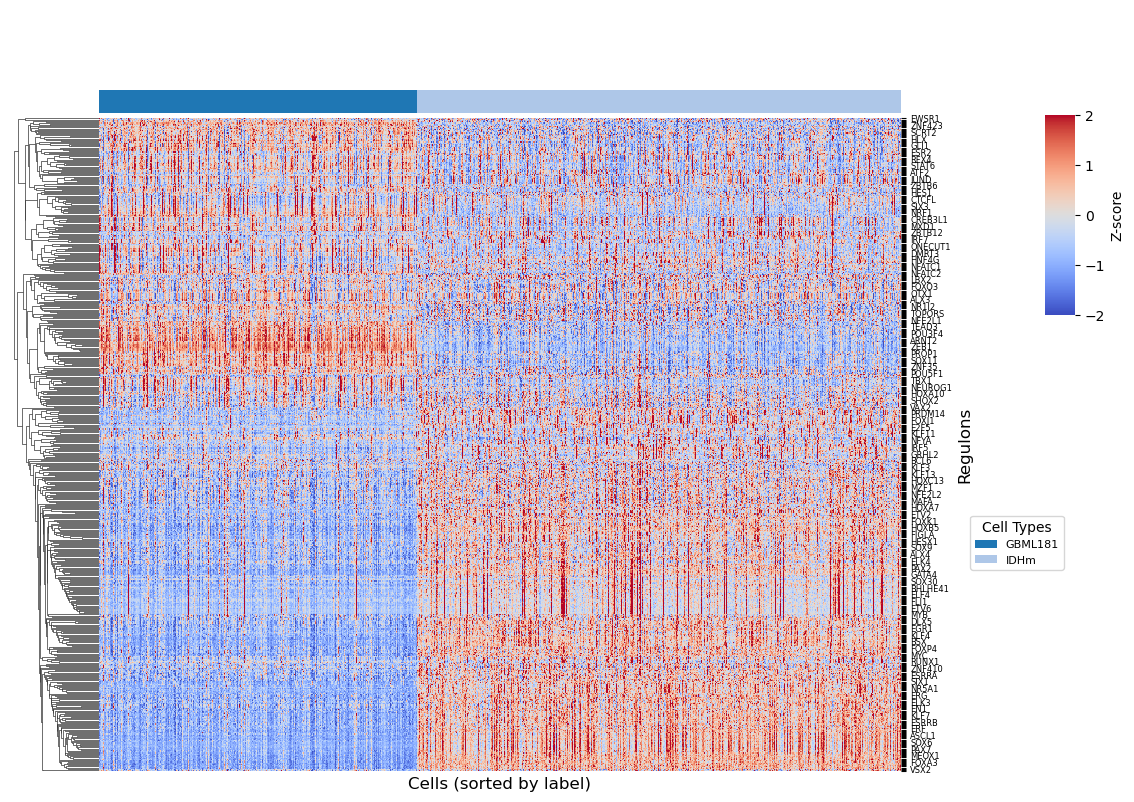

In [13]:
save=False
heatmap_cluster(TF_activity,adata_RNA,save,outdir)

RUNX3 activity p-value: 0.0
RUNX3 expression p-value: 0.34278715769989865
SOX11 activity p-value: 0.0
SOX11 expression p-value: 1.4761101245596848e-108


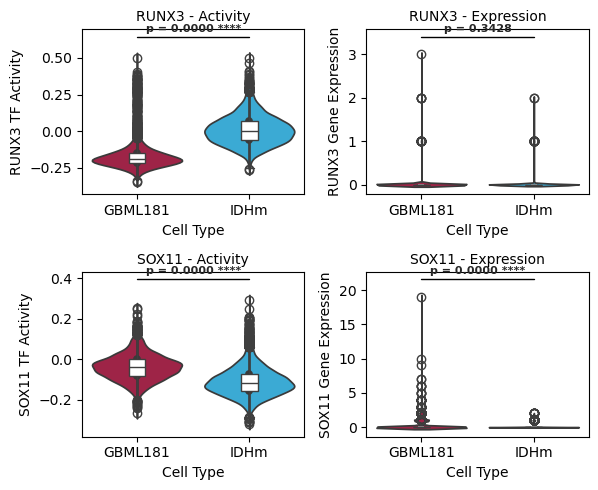

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
plt.subplots_adjust(wspace=0.25, hspace=0.3)

plots_config = [
    ('RUNX3', 'activity', axes[0, 0]),
    ('RUNX3', 'expression', axes[0, 1]),
    ('SOX11', 'activity', axes[1, 0]),
    ('SOX11', 'expression', axes[1, 1]),
]


for TFName, datatype, ax in plots_config:
    _, p_val = box_comp(
        TFName=TFName,
        adata_RNA=adata_RNA,
        celltype1='GBML181',
        celltype2='IDHm',
        datatype=datatype,
        regulon_score=TF_activity,
        save=False,
        outdir=outdir,
        ax=ax
    )
    print(f"{TFName} {datatype} p-value: {p_val}")


plt.tight_layout()
plt.savefig(outdir + "RUNX3_SOX11_4panel_combined.pdf", dpi=300, bbox_inches='tight')
plt.savefig(outdir + "RUNX3_SOX11_4panel_combined.png", dpi=300, bbox_inches='tight')
plt.show()